<a href="https://colab.research.google.com/github/Panini783/machineLearn/blob/main/%D0%9B%D0%A0_2_2_%D0%A1%D0%BB%D1%8E%D1%81%D0%B0%D1%80_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Заванажуєм дата сет за посиланням та кидаємо в колаб

In [2]:
# Завантажити з комп’ютера
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


2.Визначити розмір датасета.


In [9]:
import pandas as pd

df = pd.read_csv("titanic.csv")
rows, columns = df.shape

print(f"Кількість рядків: {rows}")
print(f"Кількість стовпців: {columns}")

Кількість рядків: 891
Кількість стовпців: 12


3.Визначити тип даних.


In [11]:
df = pd.read_csv("titanic.csv")  # заміни на шлях до свого файлу
print(df.dtypes)

df.info()

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2

4.Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.
Перевірити наявність дублікатів




In [12]:
# 1. Перевірка пропущених значень
print("Пропущені значення до заповнення:")
print(df.isna().sum())

# 2. Заміна пропусків середнім у числових стовпцях
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("\nПропущені значення після заповнення:")
print(df.isna().sum())

# 3. Перевірка дублікатів
duplicate_count = df.duplicated().sum()
print(f"\nКількість рядків-дублікатів: {duplicate_count}")

# За потреби переглянути самі дублікати:
display(df[df.duplicated(keep=False)])

Пропущені значення до заповнення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Пропущені значення після заповнення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Кількість рядків-дублікатів: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


Вирішили пропущені значення замінити на медіану (а можна на середнє)

In [13]:
# Кількість пропусків до заповнення
print("До:")
print(df.isna().sum())

# Заповнення пропусків медіаною в числових стовпцях
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Перевірка результату
print("\nПісля:")
print(df.isna().sum())

# Перевірка дублікатів
print("\nКількість дублікатів:", df.duplicated().sum())

До:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Після:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Кількість дублікатів: 0


5.Ще раз перевірити наявність пропущених значень.

In [14]:
print("Пропуски в кожному стовпці:")
print(df.isna().sum())

print("\nУсього пропусків у датасеті:", df.isna().sum().sum())

Пропуски в кожному стовпці:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Усього пропусків у датасеті: 689


6.Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [15]:
columns = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
selected_df = df[columns].copy()

display(selected_df.head())
print("Розмір нового датасету:", selected_df.shape)
print("Пропущені значення:")
print(selected_df.isna().sum())

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


Розмір нового датасету: (891, 5)
Пропущені значення:
Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64


7.Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [17]:
print("Унікальні значення Sex:")
print(selected_df["Sex"].value_counts(dropna=False))

selected_df["Sex"] = selected_df["Sex"].map({
    "male": 0,
    "female": 1
})

print("\nПісля заміни:")
print(selected_df["Sex"].value_counts(dropna=False))
print("Пропусків у Sex:", selected_df["Sex"].isna().sum())

Унікальні значення Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Після заміни:
Sex
0    577
1    314
Name: count, dtype: int64
Пропусків у Sex: 0


8.Вивести описову статистику датасету describe()

In [19]:
display(selected_df.describe())



,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,13.002015,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,29.699118,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,13.002015,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,29.699118,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9.Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [20]:
print("Пропуски за стовпцями:")
print(selected_df.isna().sum())

total_missing = selected_df.isna().sum().sum()
print(f"\nУсього пропущених значень: {total_missing}")

if total_missing == 0:
    print("Пропущених значень немає.")
else:
    print("У датасеті залишилися пропущені значення.")

Пропуски за стовпцями:
Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

Усього пропущених значень: 0
Пропущених значень немає.


10.Вивести 5 перших рядків датасету.

In [21]:
display(selected_df.head())

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11.Вивести 5 останніх рядків датасету.

In [22]:
display(selected_df.tail())

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.000000,13.00
887,1,1,1,19.000000,30.00
888,0,3,1,29.699118,23.45
889,1,1,0,26.000000,30.00
890,0,3,0,32.000000,7.75


12.Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [23]:
# Перевірка значень перед розрахунком
print("Sex:", selected_df["Sex"].unique())
print("Survived:", selected_df["Survived"].unique())

survival_by_sex = (
    selected_df.groupby("Sex")["Survived"]
    .agg(пасажирів="count", вижило="sum", частка="mean")
)

survival_by_sex["вижило_%"] = (
    survival_by_sex["частка"] * 100
).round(2)

display(survival_by_sex.drop(columns="частка"))

Sex: [0 1]
Survived: [0 1]


,пасажирів,вижило,вижило_%
Sex,,,
0,577,109,18.89
1,314,233,74.20


13.Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [24]:
survival_by_class = (
    selected_df.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

print("Відсоток виживання за класами:")
print(survival_by_class)

best_class = survival_by_class.idxmax()
print(f"\nНайвищий рівень виживання: {best_class}-й клас "
      f"({survival_by_class.loc[best_class]:.2f}%)")

Відсоток виживання за класами:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Найвищий рівень виживання: 1-й клас (62.96%)


Найвищий рівень виживання мав 1-й клас (Pclass = 1). У датасеті Titanic він становить 62,96%, порівняно з 47,28% у 2-го класу та 24,24% у 3-го

14.Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [25]:
mean_age = selected_df.groupby("Survived")["Age"].mean()

print(f"Середній вік тих, хто не вижив: {mean_age.loc[0]:.2f} року")
print(f"Середній вік тих, хто вижив:    {mean_age.loc[1]:.2f} року")
print(f"Різниця: {abs(mean_age.loc[1] - mean_age.loc[0]):.2f} року")

Середній вік тих, хто не вижив: 30.42 року
Середній вік тих, хто вижив:    28.55 року
Різниця: 1.87 року


Середній вік пасажирів, які не вижили, становив 30 років, а тих, хто вижив, — 28 років. Різниця становить майже 2 роки(1,87 року). Отже, у цьому датасеті ті, хто вижив, були в середньому трохи молодшими. Проте різниця невелика, і лише за порівнянням середніх не можна стверджувати, що вік сам по собі визначав шанси на виживання.

15.Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [29]:
fare_stats = (
    selected_df
    .groupby("Fare_group", observed=True)
    .agg(
        Пасажирів=("Survived", "count"),
        Вижило=("Survived", "sum"),
        Середній_тариф=("Fare", "mean"),
        Відсоток_виживання=("Survived", "mean")
    )
)

fare_stats["Відсоток_виживання"] = (
    fare_stats["Відсоток_виживання"] * 100
).round(2)

display(fare_stats)

,Пасажирів,Вижило,Середній_тариф,Відсоток_виживання
Fare_group,,,,
"(-0.001, 7.91]",223,44,7.034172,19.73
"(7.91, 14.454]",224,68,10.386050,30.36
"(14.454, 31.0]",222,101,23.028677,45.50
"(31.0, 512.329]",222,129,88.677872,58.11


пасажири з дорожчими квитками виживали частіше; різниця між крайніми групами становила 38,38 відсоткового пункту.

16.Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [30]:
average_fare_by_class = (
    selected_df.groupby("Pclass")["Fare"]
    .agg(пасажирів="count", середній_тариф="mean")
)

average_fare_by_class["середній_тариф"] = (
    average_fare_by_class["середній_тариф"].round(2)
)

display(average_fare_by_class)

,пасажирів,середній_тариф
Pclass,,
1,216,84.15
2,184,20.66
3,491,13.68


Так, середні тарифи помітно відрізняються між класами: у 1-му класі середній Fare становить 84,15, у 2-му — 20,66, у 3-му — 13,68. Найбільша різниця — між 1-м і 3-м класами: приблизно 70,48 одиниці тарифу

17.Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

Середній вік залежно від виживання:


,Кількість,Середній_вік
Survived,,
Не вижили,549,30.03
Вижили,342,28.29


Різниця середнього віку: 1.74 року


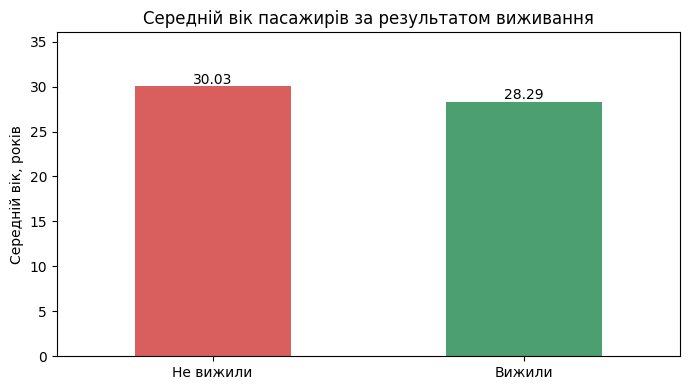

In [32]:
import matplotlib.pyplot as plt

# Аналітична частина
age_stats = (
    selected_df.groupby("Survived")["Age"]
    .agg(Кількість="count", Середній_вік="mean")
)

age_stats.index = age_stats.index.map({
    0: "Не вижили",
    1: "Вижили"
})

print("Середній вік залежно від виживання:")
display(age_stats.round(2))

difference = (
    age_stats.loc["Не вижили", "Середній_вік"]
    - age_stats.loc["Вижили", "Середній_вік"]
)
print(f"Різниця середнього віку: {difference:.2f} року")

# Графічна частина
ax = age_stats["Середній_вік"].plot(
    kind="bar",
    figsize=(7, 4),
    color=["#d95f5f", "#4c9f70"],
    rot=0
)

ax.set_title("Середній вік пасажирів за результатом виживання")
ax.set_xlabel("")
ax.set_ylabel("Середній вік, років")
ax.set_ylim(0, age_stats["Середній_вік"].max() * 1.2)

for i, value in enumerate(age_stats["Середній_вік"]):
    ax.text(i, value + 0.3, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

# Clalculate survival rate per class per sex

In [33]:
survival_class_sex = (
    selected_df.groupby(["Pclass", "Sex"])["Survived"]
    .agg(Пасажирів="count", Вижило="sum", Рівень_виживання="mean")
)

survival_class_sex["Рівень_виживання_%"] = (
    survival_class_sex["Рівень_виживання"] * 100
).round(2)

display(survival_class_sex.drop(columns="Рівень_виживання"))

Пасажирів  Вижило  Рівень_виживання_%
Pclass Sex                                          
1      female         94      91               96.81
       male          122      45               36.89
2      female         76      70               92.11
       male          108      17               15.74
3      female        144      72               50.00
       male          347      47               13.54

Побудувати теплову карту коретляції

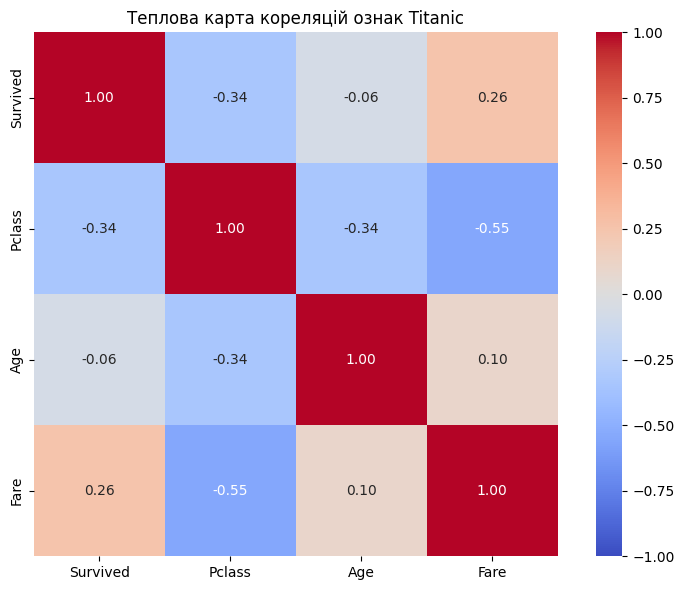

In [34]:
import seaborn as sns

# Беремо лише числові стовпці
numeric_df = selected_df.select_dtypes(include="number")

# Обчислюємо кореляцію
corr_matrix = numeric_df.corr()

# Будуємо теплову карту
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,       # показати числа в клітинках
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Теплова карта кореляцій ознак Titanic")
plt.tight_layout()
plt.show()